# **Anatomia dos Indicadores Pedagógicos 2022-2024**

# importação de dados e bibliotecas

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score

In [49]:
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
PALETA_ANO = {2022: "#4C72B0", 2023: "#DD8452", 2024: "#55A868"}

In [50]:
df = pd.read_excel("/content/BASE DE DADOS PEDE 2024 - DATATHON (2).xlsx")

In [51]:
print(df.head())

    Ano    RA  Fase Turma     Nome  Ano nasc  Idade      Gênero  Ano ingresso  \
0  2022  RA-1     7     A  Aluno-1      2003      19   Feminino          2016   
1  2022  RA-2     7     A  Aluno-2      2005      17   Feminino          2017   
2  2022  RA-3     7     A  Aluno-3      2005      17   Feminino          2016   
3  2022  RA-4     7     A  Aluno-4      2005      17  Masculino          2017   
4  2022  RA-5     7     A  Aluno-5      2005      17   Feminino          2016   

  Instituição de ensino  ... Inglês Indicado Atingiu PV    IPV   IAN  \
0        Escola Pública  ...    6.0      Sim        Não  7.278   5.0   
1          Rede Decisão  ...    9.7      Não        Não  6.778  10.0   
2          Rede Decisão  ...    6.9      Não        Não  7.556  10.0   
3          Rede Decisão  ...    8.7      Não        Não  5.278  10.0   
4          Rede Decisão  ...    5.7      Não        Não  7.389  10.0   

                Fase ideal  Defas  \
0  Fase 8 (Universitários)     -1   
1     

In [52]:
contagem_ano = df.groupby("Ano")["Nome"].nunique().reset_index()
contagem_ano.columns = ["Ano", "Quantidade"]
print(contagem_ano)

    Ano  Quantidade
0  2022         860
1  2023        1014
2  2024        1156


In [53]:
df.columns = df.columns.str.strip()

RENOMEIA = {
    "Idade": "idade", "Mat": "mat", "Matem": "mat", "Por": "por", "Portug": "por",
    "Inglês": "ing", "Defas": "defas", "Defasagem": "defas",
    "Fase ideal": "fase_ideal", "Fase Ideal": "fase_ideal",
    "Nome": "nome", "Gênero": "genero", "Instituição de ensino": "instituicao",
    "Fase": "fase_orig", "Ano": "ano",
}
for col in df.columns:
    if col.upper().startswith("INDE"):
        RENOMEIA[col] = "inde"

df = df.rename(columns=RENOMEIA)
df["atingiu_pv"] = df["Atingiu PV"].map({"Sim": 1, "Não": 0})

In [54]:

raw = {a: pd.read_excel(caminho, sheet_name=f"PEDE{a}") for a in (2022, 2023, 2024)}
for a, d in raw.items():
    print(f"PEDE{a}: {d.shape[0]} alunos, {d.shape[1]} colunas")

PEDE2022: 860 alunos, 42 colunas
PEDE2023: 1014 alunos, 48 colunas
PEDE2024: 1156 alunos, 50 colunas


In [55]:
import re
def fase_para_num(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().upper()
    if s.startswith("ALFA"):
        return 0
    m = re.search(r"\d", s)
    if not m:
        return np.nan
    n = int(m.group())
    return 8 if n == 9 else n

df["fase_num"] = df["fase_orig"].map(fase_para_num)

In [56]:
alunos_2022 = set(df[df["ano"] == 2022]["RA"])
alunos_2023 = set(df[df["ano"] == 2023]["RA"])
alunos_2024 = set(df[df["ano"] == 2024]["RA"])
alunos_2022_2023 = alunos_2022 & alunos_2023
alunos_2023_2024 = alunos_2023 & alunos_2024
alunos_3_anos = alunos_2022 & alunos_2023 & alunos_2024
print(f"alunos em 2022-2023: {len(alunos_2022_2023)}")
print(f"alunos em 2023-2024: {len(alunos_2023_2024)}")
print(f"alunos em 3 anos: {len(alunos_3_anos)}")

alunos em 2022-2023: 600
alunos em 2023-2024: 765
alunos em 3 anos: 468


# IAN — Perfil de defasagem e sua evolução

In [57]:
ORDEM_IAN = ["Grave (defas. ≤ -3)", "Moderada (-1 a -2)", "Em dia ou adiantado (≥ 0)"]
df["ian_cat"] = pd.Categorical(df["IAN"].map({2.5: ORDEM_IAN[0], 5.0: ORDEM_IAN[1], 10.0: ORDEM_IAN[2]}),
                               categories=ORDEM_IAN, ordered=True)

In [58]:
print("Relação entre IAN e Defasagem (todos os anos):")
print(pd.crosstab(df["IAN"], df["defas"]).to_string())
print("\n→ O IAN é uma discretização da defasagem: 10 = sem defasagem; 5 = defasagem de 1 a 2 fases; 2,5 = 3 ou mais.")

Relação entre IAN e Defasagem (todos os anos):
defas  -5  -4  -3   -2    -1     0    1   2   3
IAN                                            
2.5     1   5  39    0     0     0    0   0   0
5.0     0   0   0  383  1259     0    0   0   0
10.0    0   0   0    0     0  1152  165  24   2

→ O IAN é uma discretização da defasagem: 10 = sem defasagem; 5 = defasagem de 1 a 2 fases; 2,5 = 3 ou mais.


In [59]:
dist = pd.crosstab(df.ano, df.ian_cat, normalize="index") * 100
dist.columns = dist.columns.astype(str)
resumo_ian = pd.DataFrame({
    "n": df.groupby("ano").size(),
    "% com alguma defasagem": df.groupby("ano")["defas"].apply(lambda s: (s < 0).mean() * 100),
    "defasagem média (fases)": df.groupby("ano")["defas"].mean(),
}).join(dist)
print(resumo_ian.round(1).to_string())

         n  % com alguma defasagem  defasagem média (fases)  Grave (defas. ≤ -3)  Moderada (-1 a -2)  Em dia ou adiantado (≥ 0)
ano                                                                                                                            
2022   860                    69.9                     -0.9                  3.3                66.6                       30.1
2023  1014                    54.4                     -0.7                  1.4                53.1                       45.6
2024  1156                    46.2                     -0.4                  0.3                45.9                       53.8


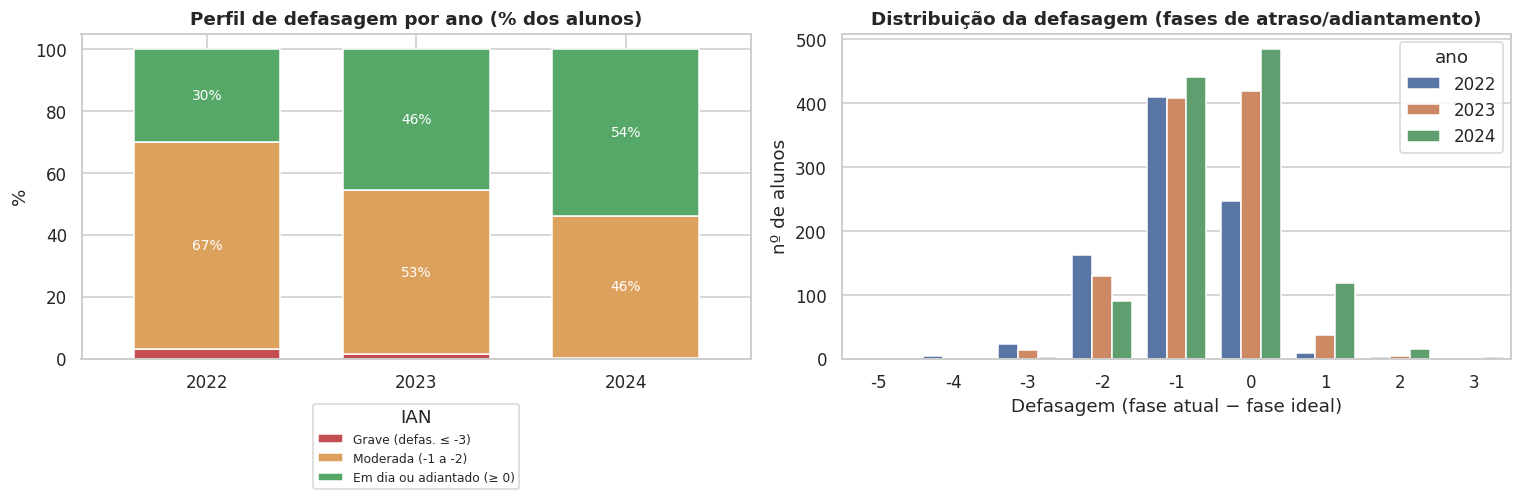

In [60]:
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
PALETA_ANO = {2022: "#4C72B0", 2023: "#DD8452", 2024: "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
dist.plot(kind="bar", stacked=True, ax=axes[0], color=["#C44E52", "#DDA15E", "#55A868"], width=.7)
axes[0].set_title("Perfil de defasagem por ano (% dos alunos)")
axes[0].set_xlabel(""); axes[0].set_ylabel("%"); axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="IAN", loc="upper center", bbox_to_anchor=(.5, -.12), ncol=1, fontsize=8)
for c in axes[0].containers:
    axes[0].bar_label(c, labels=[f"{v:.0f}%" if v >= 4 else "" for v in c.datavalues], label_type="center", fontsize=9, color="white")

sns.countplot(data=df, x="defas", hue="ano", palette=PALETA_ANO, ax=axes[1])
axes[1].set_title("Distribuição da defasagem (fases de atraso/adiantamento)")
axes[1].set_xlabel("Defasagem (fase atual − fase ideal)"); axes[1].set_ylabel("nº de alunos")
plt.tight_layout(); plt.show()

In [61]:
hm = df.pivot_table(index="fase_num", columns="ano", values="defas", aggfunc=lambda s: (s < 0).mean() * 100)
n_hm = df.pivot_table(index="fase_num", columns="ano", values="defas", aggfunc="count")
N_MIN_CELULA = 15
sns.heatmap(hm.where(n_hm >= N_MIN_CELULA), annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100, ax=axes[0],
            cbar_kws={"label": "% com defasagem"})

print(f"% de alunos com defasagem por fase e ano")
print(hm.where(n_hm >= N_MIN_CELULA).round(0).to_string())

% de alunos com defasagem por fase e ano
ano       2022  2023  2024
fase_num                  
0         64.0  51.0  75.0
1         84.0  76.0  71.0
2         72.0  62.0  37.0
3         55.0  48.0  26.0
4         66.0  48.0  56.0
5         73.0  63.0  56.0
6         83.0  73.0  48.0
7         76.0  26.0   0.0
8          NaN   0.0   0.0


Através dos gráficos e estatística gerados é possível perceber que a defasagem vem diminuindo a cada ano, casos de alunos com algum atraso caíram de por volta de 70% em 2022 para por volta de 46% em 2024, e a defasagem mais grave praticamente desapareceu, para analise foi feito um cruzamento do IAN com a defasagem sendo a fase atual – fase ideal, mostrando a composição por ano, a defasagem concentrada por fase e a trajetória dos alunos entre os anos.
A defasagem caiu de forma consistente sendo 69,9% (2022) -> 54,4% (2023) -> 46,2% (2024). Tendo alunos em dia ou adiantados aumentando 30,1% (2022) -> 45,6% (2023) -> 53,8% (2024), e a defasagem grave diminuindo bastante de 3,3% para 0,3% em 2024. A fase 1 tem o maio nível de defasagem sendo 71% e as fases 2 e 3 melhoram muito indo de 72% para 37% e 55% para 26% consecutivamente.

# IDA — Desempenho acadêmico e sua evolução

In [62]:
zeros_ausente = ["IEG", "IAA", "IDA"]
for c in zeros_ausente:
    df.loc[df[c] == 0, c] = np.nan

ida = df.dropna(subset=["IDA"])
res = ida.groupby("ano")["IDA"].agg(n="count", media="mean", mediana="median", dp="std")
res["ic95"] = 1.96 * res.dp / np.sqrt(res.n)
print(res.round(2).to_string())

         n  media  mediana    dp  ic95
ano                                   
2022   854   6.14     6.40  1.99  0.13
2023   936   6.67     6.80  1.58  0.10
2024  1039   6.45     6.75  2.00  0.12


In [63]:
n_fase = ida.pivot_table(index="fase_num", columns="ano", values="IDA", aggfunc="count")
print("nº de alunos com IDA por fase e ano (atenção às fases com n pequeno):")
print(n_fase.T.to_string())
med_fase = ida.pivot_table(index="fase_num", columns="ano", values="IDA", aggfunc="mean")
print(f"\nIDA médio por fase e ano (n < {N_MIN_CELULA} omitido):")
print(med_fase.where(n_fase >= N_MIN_CELULA).round(2).to_string())

nº de alunos com IDA por fase e ano (atenção às fases com n pequeno):
fase_num      0      1      2      3      4     5     6     7    8
ano                                                               
2022      190.0  191.0  154.0  145.0   76.0  59.0  18.0  21.0  NaN
2023      230.0  173.0  199.0  132.0   94.0  65.0  33.0  10.0  NaN
2024      194.0  182.0  184.0  209.0  115.0  99.0  25.0  30.0  1.0

IDA médio por fase e ano (n < 15 omitido):
ano       2022  2023  2024
fase_num                  
0         7.14  7.45  7.40
1         6.50  6.81  6.90
2         5.44  6.74  6.28
3         5.25  5.75  5.40
4         6.05  6.00  5.88
5         5.97  5.90  6.52
6         6.69  6.81  7.23
7         5.25   NaN  7.17
8          NaN   NaN   NaN


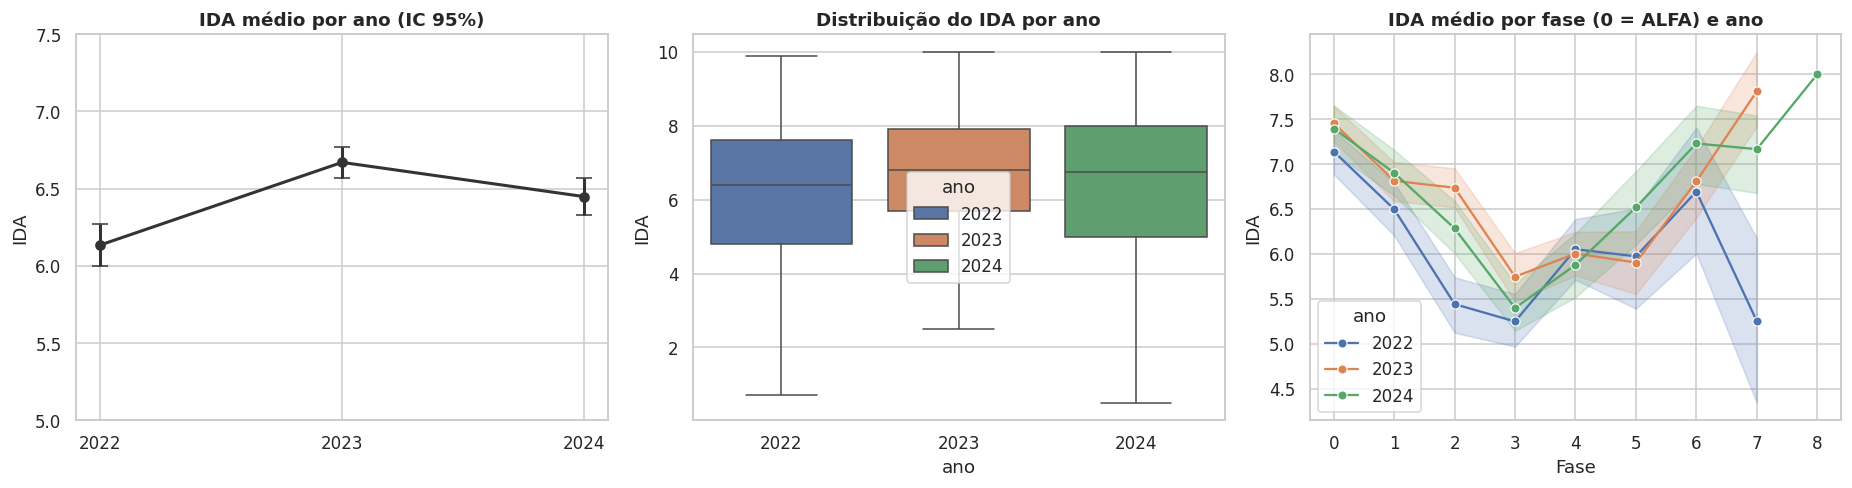

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
axes[0].errorbar(res.index, res["media"], yerr=res["ic95"], fmt="o-", capsize=5, color="#333", lw=2)
axes[0].set_xticks(res.index); axes[0].set_title("IDA médio por ano (IC 95%)"); axes[0].set_ylabel("IDA"); axes[0].set_ylim(5, 7.5)
sns.boxplot(data=ida, x="ano", y="IDA", hue="ano", palette=PALETA_ANO, ax=axes[1], showfliers=False)
axes[1].set_title("Distribuição do IDA por ano")
sns.lineplot(data=ida, x="fase_num", y="IDA", hue="ano", palette=PALETA_ANO, marker="o", errorbar=("ci", 95), ax=axes[2])
axes[2].set_title("IDA médio por fase (0 = ALFA) e ano"); axes[2].set_xlabel("Fase")
plt.tight_layout(); plt.show()

Através dos gráficos e estatística gerados é possível ver que a média geral tem uma pequena melhora de 6,1% para 6,5% indicando mais uma estabilidade ao longo dos anos, principalmente pelo fato do ao de 2023 ter chegado a 6,7% mas por não ter mantido o crescimento no ano seguinte de 2024, e ter tido uma pequena queda na média no ano seguinte, indica que o desempenho acadêmico é mais estagnado. O IDA passa por uma pequena alta de 2022 para 2023 e depois uma pequena baixa de 2023 para 2024, e esse efeito pode ser devido a entrada de novos alunos. Verificando os mesmos alunos presentes nos 3 anos temos uma queda na media sendo: 6,68% (2022) -> 6,79% (2023) -> 6,29 (2024) demonstrando uma queda minimamente maior que uma geral com todos os alunos. A trajetória individual consiste em de 2023 -> 2024 46% dos alunos perderam mais de 0,5 pontos, 30% ganharam e 24% ficaram estáveis. Já de 2022 -> 2023 38% dos alunos perderam pontos, 36% ganharam e 26% ficaram estáveis

# IEG x IDA e IPV – Engajamento, desempenho e ponto de virada

In [65]:
def spearman(x, y):
    d = pd.concat([x, y], axis=1).dropna()
    if len(d) < 5:
        return np.nan, np.nan, len(d)
    r, p = stats.spearmanr(d.iloc[:, 0], d.iloc[:, 1])
    return r, p, len(d)

linhas = []
for a, g in df.groupby("ano"):
    for alvo in ["IDA", "IPV"]:
        r, p, n = spearman(g.IEG, g[alvo])
        linhas.append(dict(ano=a, relacao=f"IEG × {alvo}", rho=r, p=p, n=n))
cor = pd.DataFrame(linhas)
print(cor.pivot(index="ano", columns="relacao", values="rho").round(3).to_string())
print("\n(p < 0.001 em todas as correlações acima)" if (cor.p < 0.001).all() else "\nValores de p:\n" + cor.round(4).to_string())


relacao  IEG × IDA  IEG × IPV
ano                          
2022         0.498      0.539
2023         0.445      0.492
2024         0.502      0.557

(p < 0.001 em todas as correlações acima)


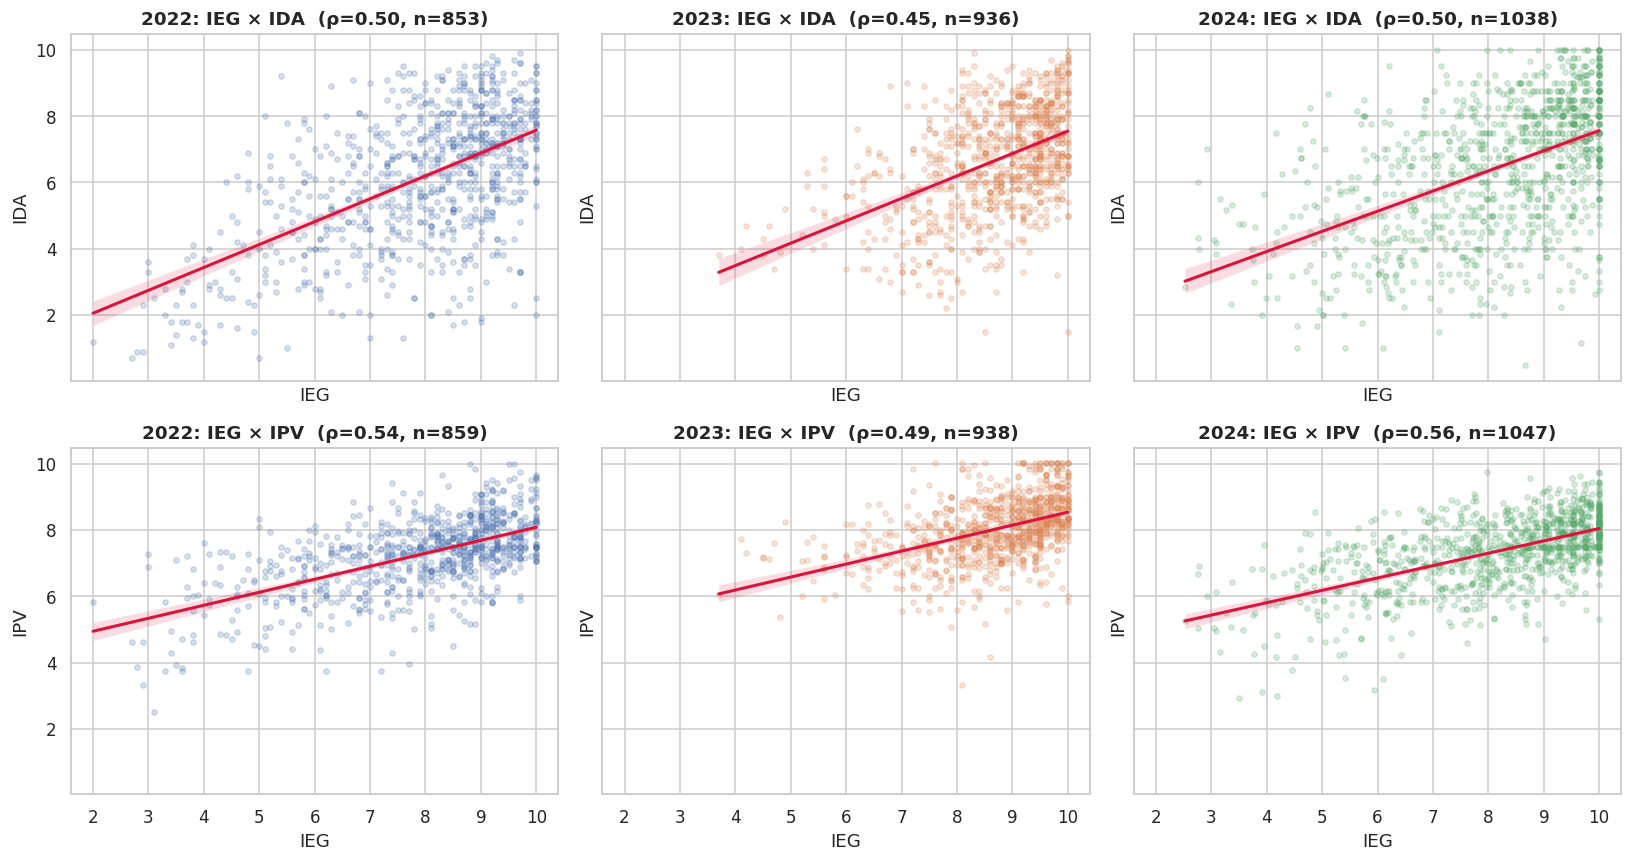

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for j, a in enumerate([2022, 2023, 2024]):
    g = df[df.ano == a]
    for i, alvo in enumerate(["IDA", "IPV"]):
        sns.regplot(data=g, x="IEG", y=alvo, ax=axes[i, j], scatter_kws=dict(alpha=.22, s=12, color=PALETA_ANO[a]),
                    line_kws=dict(color="crimson", lw=2))
        r, _, n = spearman(g.IEG, g[alvo])
        axes[i, j].set_title(f"{a}: IEG × {alvo}  (ρ={r:.2f}, n={n})")
plt.tight_layout(); plt.show()

In [67]:
def qcut_por_ano(base, col, labels):
    out = []
    for _, g in base.groupby("ano"):
        out.append(pd.qcut(g[col].rank(method="first"), len(labels), labels=labels))
    return pd.concat(out).reindex(base.index)

QL = ["Q1 (menor IEG)", "Q2", "Q3", "Q4 (maior IEG)"]
df["ieg_q"] = qcut_por_ano(df.dropna(subset=["IEG"]), "IEG", QL).reindex(df.index)
q = df.dropna(subset=["IEG"]).groupby(["ano", "ieg_q"], observed=True)[["IDA", "IPV"]].mean().reset_index()
print("Diferença Q4 − Q1 (pontos):")
piv = q.pivot(index="ano", columns="ieg_q", values=["IDA", "IPV"])
print(pd.DataFrame({alvo: piv[alvo][QL[-1]] - piv[alvo][QL[0]] for alvo in ["IDA", "IPV"]}).round(2).to_string())

Diferença Q4 − Q1 (pontos):
       IDA   IPV
ano             
2022  2.66  1.55
2023  1.87  1.16
2024  2.60  1.52


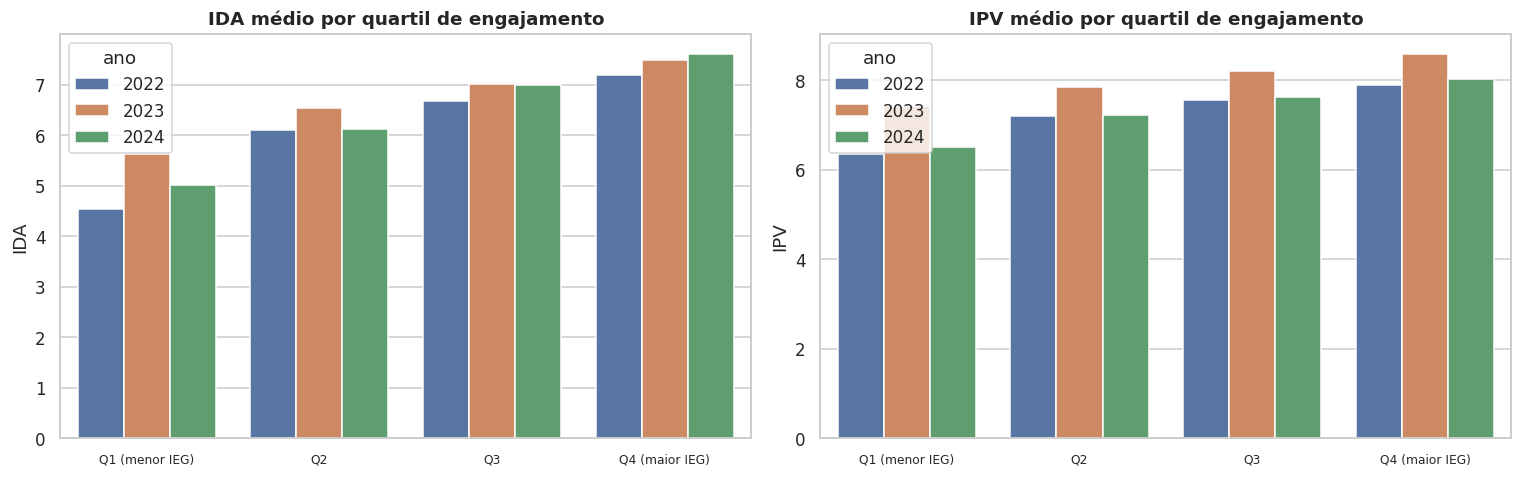

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, alvo in zip(axes, ["IDA", "IPV"]):
    sns.barplot(data=q, x="ieg_q", y=alvo, hue="ano", palette=PALETA_ANO, ax=ax)
    ax.set_title(f"{alvo} médio por quartil de engajamento")
    ax.set_xlabel(""); ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

Através dos gráficos e estatística gerados a forte relação existente do engajamento com o desempenho (sendo p = 0,45 - 0,50) e o ponto de virada (sendo p = 0,49 – 0,56) mesmo com fase idade e ano, e a relação também aparece nas mudanças ao longo do tempo. Para analise foi feito a correlação entre IEG e IDA/IPV por ano, comparado com o engajamento, ajustando a regressão com fase, idade e ano. engajamento e desempenho andam juntos, de forma estável nos 3 anos, tendo correlação IEG x IDA entre 0,49 e 0,56. Quem aumentou o engajamento tendeu a aumentar o desempenho no ano seguinte. Teve uma diferença entre o quartil de menor e maior engajamento, o IDA difere em 1,9 a 2,7 pontos e o IPV em 1,2 a 1,6 pontos a mais.

# IAA x IDA e IEG – Coerência na autopercepção

In [69]:
LIMIAR_PERCEPCAO = 1.0

df["gap_ida"] = df.IAA - df.IDA
df["gap_ieg"] = df.IAA - df.IEG
df["percepcao"] = pd.cut(df.gap_ida, [-np.inf, -LIMIAR_PERCEPCAO, LIMIAR_PERCEPCAO, np.inf],
                         labels=["Subestima", "Coerente", "Superestima"])

linhas = []
for a, g in df.groupby("ano"):
    for alvo in ["IDA", "IEG"]:
        r, p, n = spearman(g.IAA, g[alvo])
        linhas.append(dict(ano=a, par=f"IAA × {alvo}", rho=r, n=n))
print("Correlação (Spearman) entre autopercepção e realidade:")
print(pd.DataFrame(linhas).pivot(index="ano", columns="par", values="rho").round(3).to_string())

med = df.groupby("ano")[["IAA", "IDA", "IEG", "gap_ida", "gap_ieg"]].mean().round(2)
print("\nMédias por ano:"); print(med.to_string())


Correlação (Spearman) entre autopercepção e realidade:
par   IAA × IDA  IAA × IEG
ano                       
2022      0.140      0.164
2023      0.109      0.131
2024      0.140      0.205

Médias por ano:
       IAA   IDA   IEG  gap_ida  gap_ieg
ano                                     
2022  8.67  6.14  7.90     2.48     0.68
2023  8.63  6.67  8.70     1.90    -0.15
2024  8.71  6.45  8.14     2.22     0.53


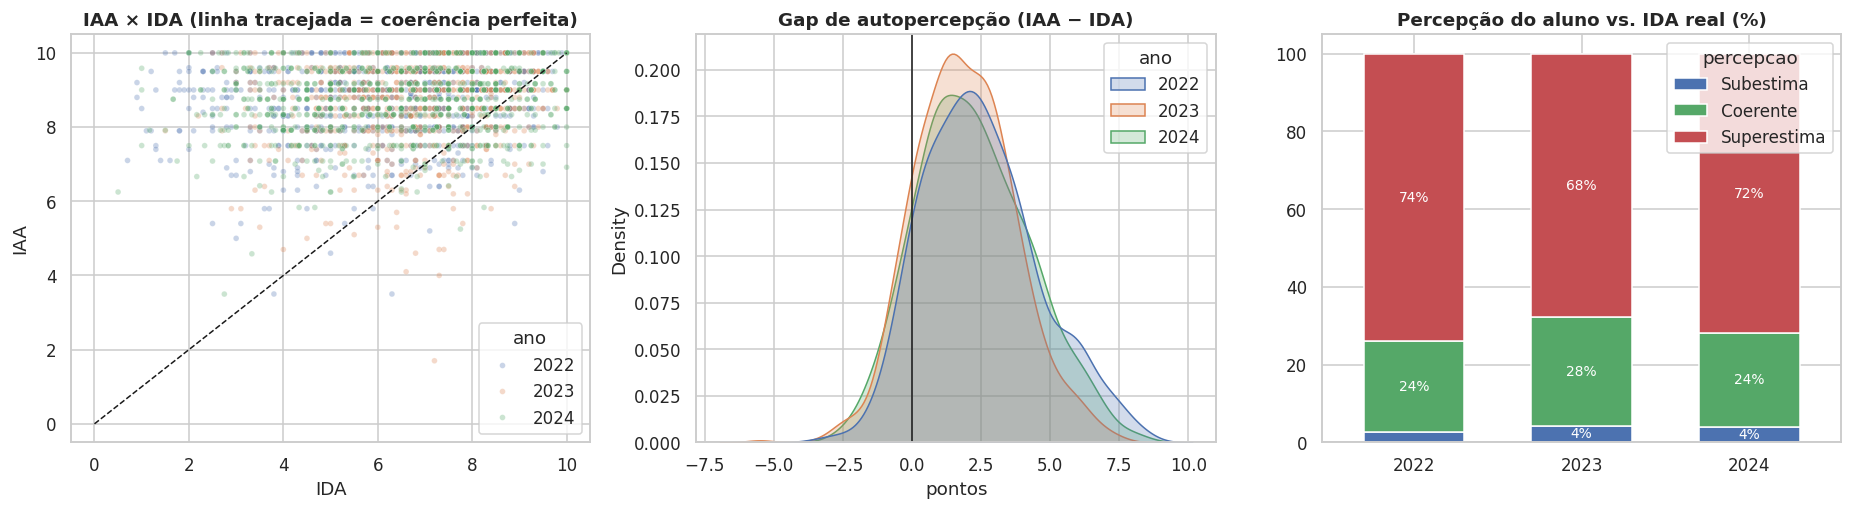

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
sns.scatterplot(data=df, x="IDA", y="IAA", hue="ano", palette=PALETA_ANO, alpha=.3, s=14, ax=axes[0])
axes[0].plot([0, 10], [0, 10], "k--", lw=1); axes[0].set_title("IAA × IDA (linha tracejada = coerência perfeita)")
sns.kdeplot(data=df.dropna(subset=["gap_ida"]), x="gap_ida", hue="ano", palette=PALETA_ANO, fill=True, alpha=.25, common_norm=False, ax=axes[1])
axes[1].axvline(0, color="k", lw=1); axes[1].set_title("Gap de autopercepção (IAA − IDA)"); axes[1].set_xlabel("pontos")
perc = pd.crosstab(df.ano, df.percepcao, normalize="index").mul(100)[["Subestima", "Coerente", "Superestima"]]
perc.plot(kind="bar", stacked=True, ax=axes[2], color=["#4C72B0", "#55A868", "#C44E52"], width=.6)
axes[2].set_title("Percepção do aluno vs. IDA real (%)"); axes[2].set_xlabel(""); axes[2].tick_params(axis="x", rotation=0)
for c in axes[2].containers:
    axes[2].bar_label(c, labels=[f"{v:.0f}%" if v >= 4 else "" for v in c.datavalues], label_type="center", fontsize=9, color="white")
plt.tight_layout(); plt.show()

In [71]:
print("\nPercepção do aluno vs. IDA real (% dos alunos com IAA e IDA):")
print(perc.round(1).to_string())


Percepção do aluno vs. IDA real (% dos alunos com IAA e IDA):
percepcao  Subestima  Coerente  Superestima
ano                                        
2022             2.7      23.5         73.8
2023             4.3      28.0         67.7
2024             4.0      24.2         71.8


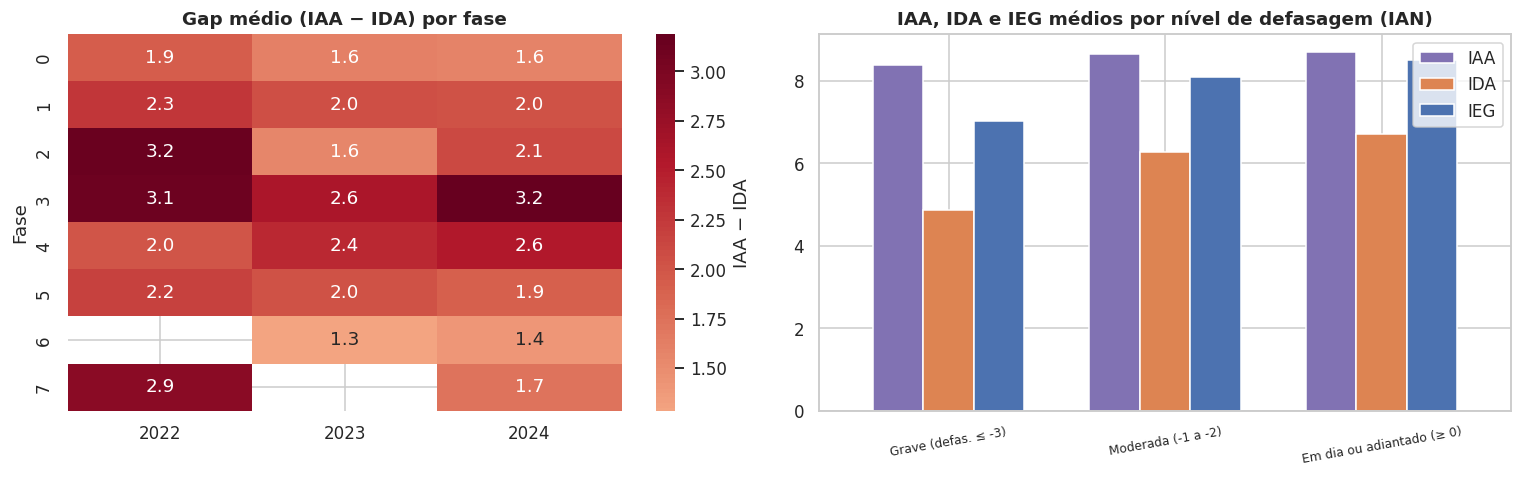

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
gap_fase = df.pivot_table(index="fase_num", columns="ano", values="gap_ida", aggfunc="mean")
n_fase = df.pivot_table(index="fase_num", columns="ano", values="gap_ida", aggfunc="count")
sns.heatmap(gap_fase.where(n_fase >= N_MIN_CELULA), annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=axes[0], cbar_kws={"label": "IAA − IDA"})
axes[0].set_title("Gap médio (IAA − IDA) por fase"); axes[0].set_ylabel("Fase"); axes[0].set_xlabel("")
por_ian = df.groupby("ian_cat", observed=True)[["IAA", "IDA", "IEG"]].mean()
por_ian.plot(kind="bar", ax=axes[1], color=["#8172B3", "#DD8452", "#4C72B0"], width=.7)
axes[1].set_title("IAA, IDA e IEG médios por nível de defasagem (IAN)"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=10, labelsize=8)
plt.tight_layout(); plt.show()

Através dos gráficos e estatística gerados é possível perceber que a autopercepção é pouco coerente com a realidade, sendo que cerca de 7 em 10 alunos superestimam o IDA em mais de 1 ponto, e a relação entre IAA e IDA é de apenas 0,11 – 0,14. Para analise foi definido o Gap de autopercepção colocando +1 ponto = superestimam, -1 = subestima e
entre -1 e +1 = coerente. Foi feito a medição da correlação, a distribuição do Gap e como ele varia. A maioria dos alunos de avaliam superior ao seu desempenho real, tendo um IAA médio de 8,6 e 8,7 nos três anos contra um IDA de 6,1 a 6,7. Com isso 68 a 74% superestimam o IDA em mais de um ponto, somente 24% a 28% sendo coerentes e 3% a 4% se subestimam. Tem um crescimento de Gap com a idade, tendo uma maior diferença entre alunos com mais dificuldades sendo: +3,45 pontos entre alunos com defasagem grave, +2,35 na moderada e +1,96 nos alunos em dia.

# IPS – Padrões psicossociais que antecedem quedas

In [73]:
print(df.groupby("ano")["IPS"].describe().round(2).to_string())

       count  mean   std   min   25%   50%   75%   max
ano                                                   
2022   860.0  6.90  1.07  2.50  6.30  7.50  7.50  10.0
2023   945.0  5.12  2.09  2.52  2.52  5.00  7.52  10.0
2024  1054.0  6.83  1.43  2.51  6.26  7.51  7.51  10.0


In [74]:
PARCOLS = ["fase_num", "idade", "genero", "IAN", "ian_cat", "defas", "IDA", "IEG", "IAA", "IPS", "ips_z", "IPV"]

df["ips_z"] = df.groupby("ano")["IPS"].transform(lambda s: (s - s.mean()) / s.std())
def montar_pares(base, a, b, cols=PARCOLS):
    x = base[base.ano == a].set_index("RA")[cols]
    y = base[base.ano == b].set_index("RA")[cols]
    p = x.join(y, how="inner", lsuffix="_t", rsuffix="_t1")
    p["par"] = f"{a}→{b}"
    return p.reset_index()


pares = pd.concat([montar_pares(df, 2022, 2023), montar_pares(df, 2023, 2024)], ignore_index=True)
LIMIAR_QUEDA = 0.5

pares["dIDA"] = pares.IDA_t1 - pares.IDA_t
pares["dIEG"] = pares.IEG_t1 - pares.IEG_t
pares["queda_ida"] = np.where(pares.dIDA.notna(), (pares.dIDA < -LIMIAR_QUEDA).astype(float), np.nan)
pares["queda_ieg"] = np.where(pares.dIEG.notna(), (pares.dIEG < -LIMIAR_QUEDA).astype(float), np.nan)
pares["ips_faixa"] = pd.cut(pares.ips_z_t, [-np.inf, -0.5, 0.5, np.inf], labels=["IPS baixo (z<-0.5)", "IPS médio", "IPS alto (z>0.5)"])

print(f"Limiar de queda: {LIMIAR_QUEDA} ponto | % de alunos que tiveram queda:")
print(pares.groupby("par")[["queda_ida", "queda_ieg"]].mean().mul(100).round(1).to_string())

for alvo in ["queda_ida", "queda_ieg"]:
    t = (pares.dropna(subset=[alvo, "ips_faixa"]).groupby(["par", "ips_faixa"], observed=True)[alvo]
         .agg(pct_queda=lambda s: s.mean() * 100, n="count").round(1))
    print(f"\n{alvo}: % com queda por faixa de IPS no ano anterior"); print(t.to_string())

Limiar de queda: 0.5 ponto | % de alunos que tiveram queda:
           queda_ida  queda_ieg
par                            
2022→2023       35.0       20.9
2023→2024       44.0       45.9

queda_ida: % com queda por faixa de IPS no ano anterior
                              pct_queda    n
par       ips_faixa                         
2022→2023 IPS baixo (z<-0.5)       37.5  176
          IPS médio                27.3   33
          IPS alto (z>0.5)         34.5  365
2023→2024 IPS baixo (z<-0.5)       45.0  269
          IPS médio                41.5  106
          IPS alto (z>0.5)         44.1  297

queda_ieg: % com queda por faixa de IPS no ano anterior
                              pct_queda    n
par       ips_faixa                         
2022→2023 IPS baixo (z<-0.5)       17.6  176
          IPS médio                27.3   33
          IPS alto (z>0.5)         21.9  365
2023→2024 IPS baixo (z<-0.5)       43.2  271
          IPS médio                53.3  107
          IPS alto (z>0

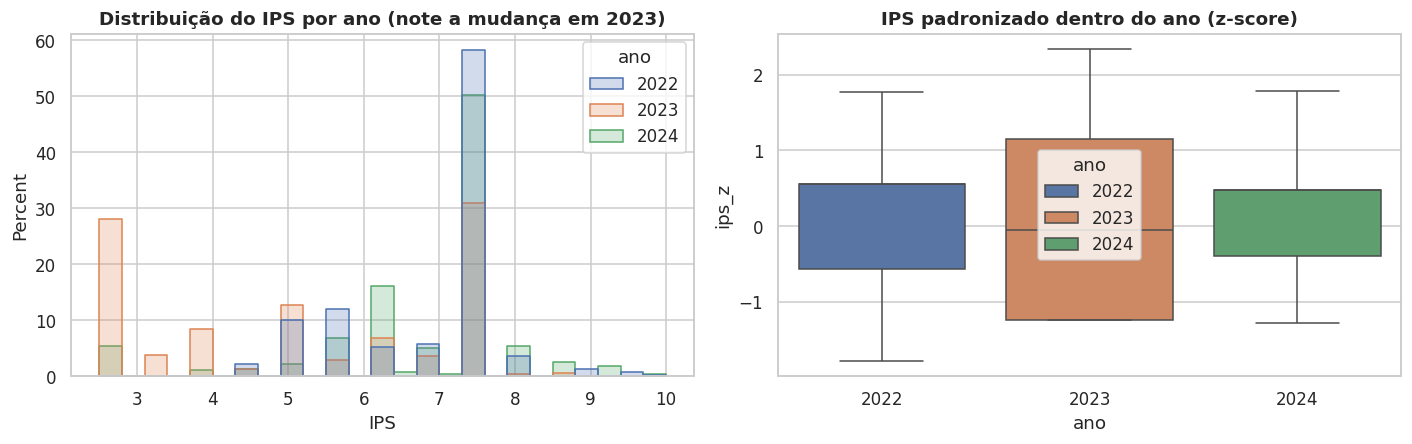

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(data=df, x="IPS", hue="ano", palette=PALETA_ANO, element="step", stat="percent", common_norm=False, bins=25, ax=axes[0])
axes[0].set_title("Distribuição do IPS por ano (note a mudança em 2023)")
sns.boxplot(data=df, x="ano", y="ips_z", hue="ano", palette=PALETA_ANO, ax=axes[1], showfliers=False)
axes[1].set_title("IPS padronizado dentro do ano (z-score)")
plt.tight_layout(); plt.show()

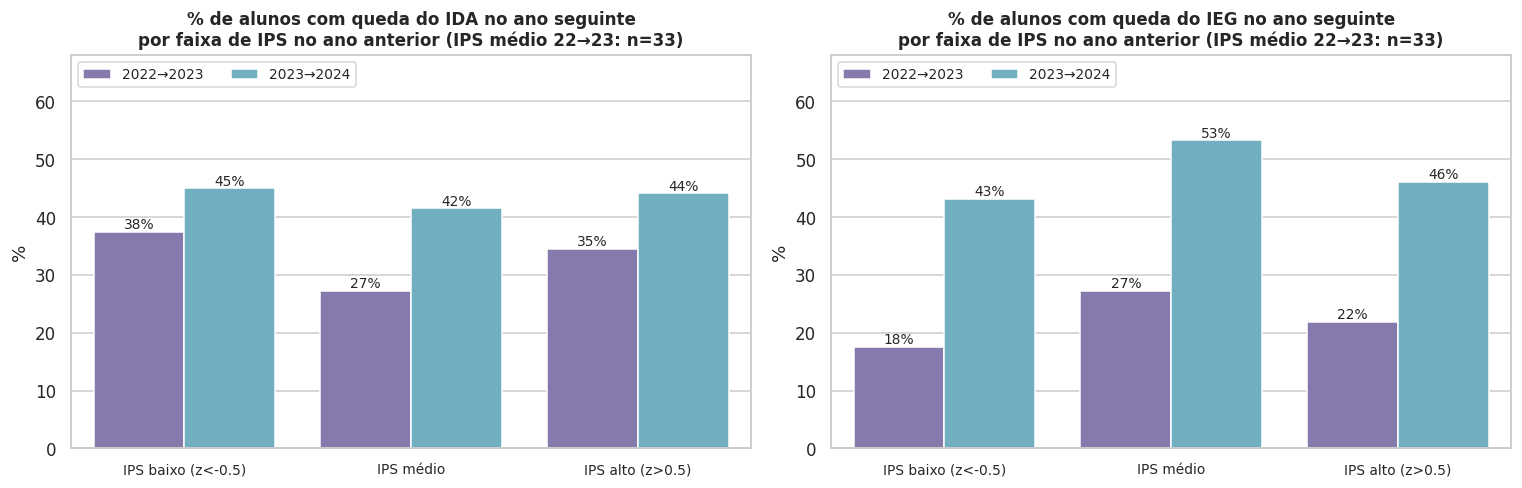

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, alvo, tit in zip(axes, ["queda_ida", "queda_ieg"], ["queda do IDA", "queda do IEG"]):
    t = pares.dropna(subset=[alvo, "ips_faixa"]).groupby(["par", "ips_faixa"], observed=True)[alvo].mean().mul(100).reset_index()
    sns.barplot(data=t, x="ips_faixa", y=alvo, hue="par", ax=ax, palette=["#8172B3", "#64B5CD"])
    ax.set_title(f"% de alunos com {tit} no ano seguinte\npor faixa de IPS no ano anterior (IPS médio 22→23: n=33)", fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("%"); ax.tick_params(axis="x", labelsize=9)
    ax.set_ylim(0, 68); ax.legend(title="", loc="upper left", ncol=2, fontsize=9)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.0f%%", fontsize=9)
plt.tight_layout(); plt.show()

Através dos gráficos e estatística gerados não é possível notar de uma forma clara que o IPS consiga anteceder quedas de desempenho ou de engajamento. Podendo ver que tendo IPS de baixo a alto o padrão praticamente se mantém, não sendo possível notar uma diferença devida ao IPS podendo
ocorrer por outros fatores. Para analise os alunos observados em dois anos consecutivos, comparamos o IPS do ano t com o que acontece em t+1. Queda = perda de mais de 0,5 ponto de IDA (ou IEG). Foi testado os alunos com três anos, se a mudança do IPS em 22→23 antecede mudanças em 23→24. Existem quedas frequentes de 35% (2022 -> 2023) e 44% (2023 -> 2024) os alunos que perderam mais de 0,5 pontos de Ida e no IEG temos 21% e 46% respectivamente. O IPS não sinaliza de forma clara pois o IPS padronizado de quem caiu é praticamente igual ao de quem não caiu (IDA: −0,02 contra +0,01, p = 0,75; IEG: p = 0,37). As taxas de queda por faixa de IPS são quase idênticas (ex.: 23→24, IDA: 45% no IPS baixo contra 44% no alto), teve um sinal no nível inicial onde +1 desvio-padrão de IPS reduz por volta de 15% a chance de queda do IDA, mas no IEG não possui efeito. a mudança de IPS em um ano, não consegue anteceder as mudanças nos anos seguintes.

# IPP x IAN — A relação entre as avaliações psicopedagógicas e a defasagem

In [77]:
caminho = "/content/BASE DE DADOS PEDE 2024 - DATATHON (2).xlsx"
ipp_2023 = pd.read_excel(caminho, sheet_name="PEDE2023")[["RA", "IPP"]].assign(ano=2023)
ipp_2024 = pd.read_excel(caminho, sheet_name="PEDE2024")[["RA", "IPP"]].assign(ano=2024)
ipp = pd.concat([ipp_2023, ipp_2024], ignore_index=True)

df = df.merge(ipp, on=["RA", "ano"], how="left")

In [78]:
def fmt_p(p):
    return "p<0.001" if p < 0.001 else f"p={p:.3f}"
print("Preenchimento da coluna 'Rec Psicologia' (não nulos):", {a: int(raw[a]["Rec Psicologia"].notna().sum()) for a in raw})
q6 = df[df.ano.isin([2023, 2024])].dropna(subset=["IPP", "IAN"]).copy()
print(f"n = {len(q6)} alunos com IPP e IAN\n")
print("IPP médio / mediana por nível de IAN:")
print(q6.groupby(["ano", "ian_cat"], observed=True)["IPP"].agg(["count", "mean", "median"]).round(2).to_string())

Preenchimento da coluna 'Rec Psicologia' (não nulos): {2022: 860, 2023: 0, 2024: 0}
n = 1992 alunos com IPP e IAN

IPP médio / mediana por nível de IAN:
                                count  mean  median
ano  ian_cat                                       
2023 Grave (defas. ≤ -3)           14  6.96    7.58
     Moderada (-1 a -2)           536  7.50    7.50
     Em dia ou adiantado (≥ 0)    388  7.67    7.81
2024 Grave (defas. ≤ -3)            3  7.26    7.03
     Moderada (-1 a -2)           531  7.41    7.50
     Em dia ou adiantado (≥ 0)    520  7.69    7.71


In [79]:
q6["ipp_faixa"] = qcut_por_ano(q6, "IPP", ["IPP baixo", "IPP médio", "IPP alto"])
tab = pd.crosstab(q6.ipp_faixa, q6.ian_cat, normalize="index").mul(100)
print("% de cada nível de IAN dentro de cada faixa de IPP:")
print(tab.round(1).to_string())

% de cada nível de IAN dentro de cada faixa de IPP:
ian_cat    Grave (defas. ≤ -3)  Moderada (-1 a -2)  Em dia ou adiantado (≥ 0)
ipp_faixa                                                                    
IPP baixo                  1.2                60.7                       38.1
IPP médio                  1.1                55.1                       43.9
IPP alto                   0.3                45.0                       54.7


In [80]:
defasados = q6[q6.ian_cat != ORDEM_IAN[2]]
em_dia = q6[q6.ian_cat == ORDEM_IAN[2]]
contra1 = (defasados.ipp_faixa == "IPP alto").mean() * 100
contra2 = (em_dia.ipp_faixa == "IPP baixo").mean() * 100
print(f"\nContradições entre as duas avaliações:")
print(f"  • {contra1:.0f}% dos alunos COM defasagem (n={len(defasados)}) têm IPP no terço superior")
print(f"  • {contra2:.0f}% dos alunos SEM defasagem (n={len(em_dia)}) têm IPP no terço inferior")


Contradições entre as duas avaliações:
  • 28% dos alunos COM defasagem (n=1084) têm IPP no terço superior
  • 28% dos alunos SEM defasagem (n=908) têm IPP no terço inferior


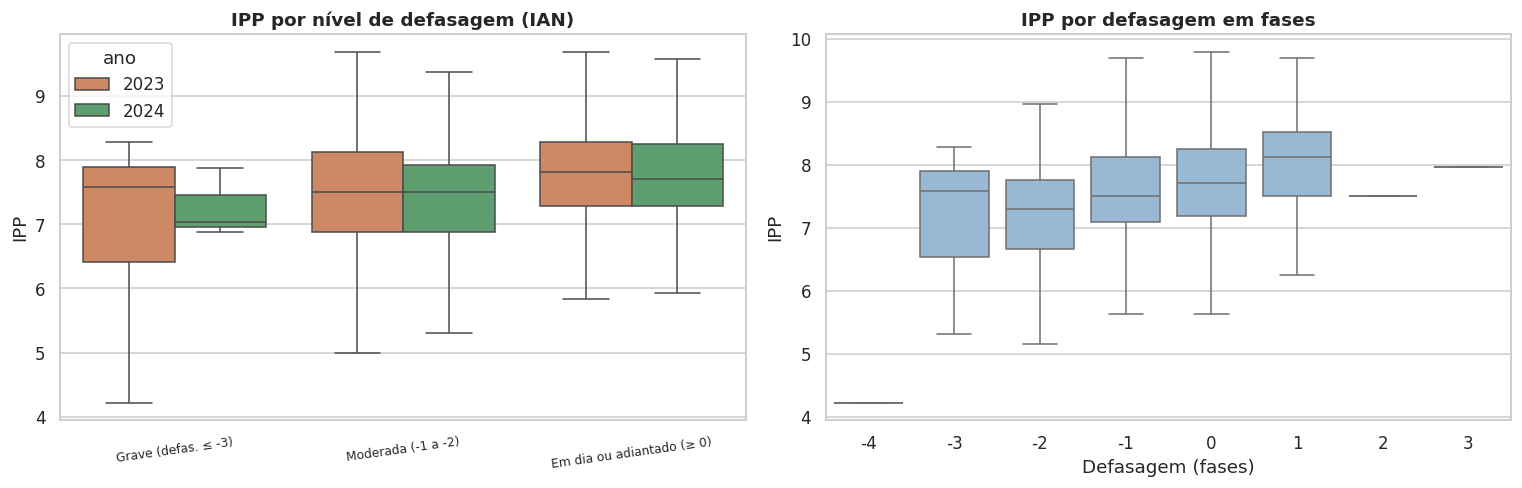

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sns.boxplot(data=q6, x="ian_cat", y="IPP", hue="ano", palette=PALETA_ANO, ax=axes[0], showfliers=False)
axes[0].set_title("IPP por nível de defasagem (IAN)"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", labelsize=8, rotation=8)
sns.boxplot(data=q6, x="defas", y="IPP", color="#8FB8DE", ax=axes[1], showfliers=False)
axes[1].set_title("IPP por defasagem em fases"); axes[1].set_xlabel("Defasagem (fases)")
plt.tight_layout(); plt.show()

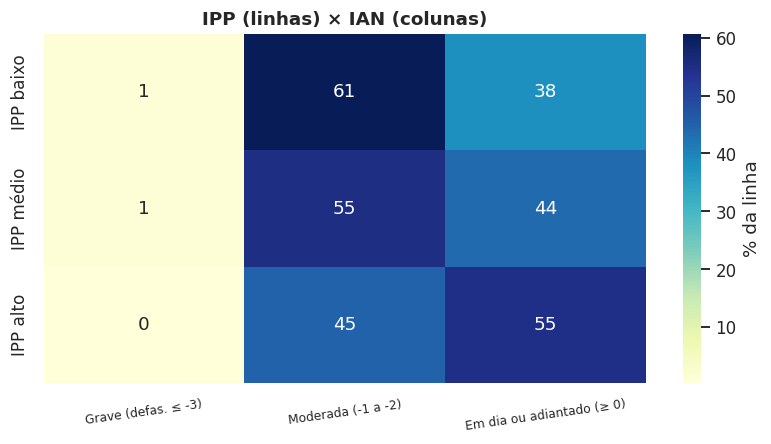

In [82]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.heatmap(tab[ORDEM_IAN], annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "% da linha"})
ax.set_title("IPP (linhas) × IAN (colunas)"); ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(axis="x", labelsize=8, rotation=8)
plt.tight_layout(); plt.show()

Através dos gráficos e estatística gerados é possível identificar uma direção onde quanto maior a defasagem menor o IPP, aparecendo com p = 0,17 (2023) e 0,19 (2024) e o IPP mediano é maior entre os
alunos em dia (7,7 - 7,8) do que entre os com defasagem moderada (7,5). Porem 28% dos alunos com defasagem possuem um IPP alto e 28% dos alunos em dia tem IPP baixo. Ou seja, é uma relação muito fraca, pois apesar de ter uma diferença de IPP entre os níveis a diferença é baixa, e existe uma boa porcentagem de alunos fugindo do padrão. Para analise como o IPP só existir em 2023-2024, foi comparado entre o IPP entre os níveis de IAN, foi medido as contradições e teve um cruzamento de informações das recomendações da psicologia com o IAN. Existe uma concordância porem muito fraca, o IPP mediano é maior entre alunos em dia (7,7 - 7,8) do que entre os com defasagem moderada (7,5). A correlação IPP × defasagem: ρ = +0,17 (2023) e +0,19 (2024). Nos terços de IPP com IPP baixo 38% dos alunos estão em dia e com IPP alto 55% estão em dia.

# IPV — A influência dos comportamentos acadêmicos, emocionais e de engajamento no IPV ao longo do tempo

In [83]:
F22 = ["IEG", "IDA", "IAA", "IPS", "defas", "idade", "fase_num"]
d22 = df[df.ano == 2022].dropna(subset=["atingiu_pv"] + F22)
print(f"2022: n={len(d22)} | atingiram o PV: {int(d22.atingiu_pv.sum())} ({d22.atingiu_pv.mean() * 100:.1f}%)\n")

2022: n=817 | atingiram o PV: 111 (13.6%)



In [84]:
linhas = []
for c in F22 + ["IPV"]:
    a, b = d22[d22.atingiu_pv == 1][c], d22[d22.atingiu_pv == 0][c]
    u = stats.mannwhitneyu(a, b)
    linhas.append(dict(variavel=c, media_atingiu=a.mean(), media_nao=b.mean(), diferenca=a.mean() - b.mean(),
                       AUC_univariada=u.statistic / (len(a) * len(b)), p=u.pvalue))
uni = pd.DataFrame(linhas).sort_values("AUC_univariada", ascending=False)
print(f"IPV mínimo entre quem atingiu o PV: {d22[d22.atingiu_pv == 1].IPV.min():.2f} | "
      f"IPV máximo entre quem não atingiu: {d22[d22.atingiu_pv == 0].IPV.max():.2f}  ")
print(uni.round(3).to_string(index=False))

IPV mínimo entre quem atingiu o PV: 8.38 | IPV máximo entre quem não atingiu: 8.33  
variavel  media_atingiu  media_nao  diferenca  AUC_univariada     p
     IPV          8.857      7.054      1.803           1.000 0.000
     IDA          7.882      5.929      1.953           0.803 0.000
     IEG          9.026      7.839      1.187           0.747 0.000
     IAA          9.027      8.615      0.412           0.623 0.000
     IPS          7.334      6.850      0.485           0.609 0.000
   defas         -0.712     -0.975      0.263           0.580 0.004
fase_num          2.333      1.992      0.342           0.540 0.166
   idade         12.126     12.033      0.094           0.506 0.844


In [85]:
Xs = (d22[F22] - d22[F22].mean()) / d22[F22].std()
lg = sm.Logit(d22.atingiu_pv, sm.add_constant(Xs)).fit(disp=0)
orr = pd.DataFrame({"OR_por_+1DP": np.exp(lg.params), "IC95_inf": np.exp(lg.conf_int()[0]), "IC95_sup": np.exp(lg.conf_int()[1]), "p": lg.pvalues}).drop("const")
auc = cross_val_score(LogisticRegression(max_iter=1000), Xs, d22.atingiu_pv, cv=5, scoring="roc_auc").mean()
print(f"\nRegressão logística multivariada — AUC em validação cruzada 5-fold: {auc:.2f}")
print(orr.round(3).sort_values("OR_por_+1DP", ascending=False).to_string())


Regressão logística multivariada — AUC em validação cruzada 5-fold: 0.85
          OR_por_+1DP  IC95_inf  IC95_sup      p
IDA             4.190     2.819     6.229  0.000
IEG             2.437     1.588     3.739  0.000
IAA             1.616     1.202     2.171  0.001
fase_num        1.587     0.470     5.359  0.457
IPS             1.363     1.042     1.782  0.024
idade           1.235     0.331     4.614  0.754
defas           1.206     0.699     2.080  0.500


In [86]:
def padroniza(d, cols):
    return (d[cols] - d[cols].mean()) / d[cols].std()


In [87]:
FA = ["IEG", "IDA", "IAA", "ips_z", "defas", "idade", "fase_num"]
dA = df.dropna(subset=["IPV"] + FA).copy()
dA[[f + "_s" for f in FA]] = padroniza(dA, FA)
mA = smf.ols("IPV ~ " + " + ".join(f + "_s" for f in FA) + " + C(ano)", data=dA).fit(cov_type="HC3")
FB = FA + ["IPP"]
dB = df[df.ano.isin([2023, 2024])].dropna(subset=["IPV"] + FB).copy()
dB[[f + "_s" for f in FB]] = padroniza(dB, FB)
mB = smf.ols("IPV ~ " + " + ".join(f + "_s" for f in FB) + " + C(ano)", data=dB).fit(cov_type="HC3")
print(f"Modelo A (2022-24, sem IPP): n={len(dA)}, R²={mA.rsquared:.3f}")
print(f"Modelo B (2023-24, com IPP): n={len(dB)}, R²={mB.rsquared:.3f}\n")

Modelo A (2022-24, sem IPP): n=2579, R²=0.487
Modelo B (2023-24, com IPP): n=1762, R²=0.624



In [88]:
def coef_tab(m, termos=None):
    t = pd.DataFrame({"coef": m.params, "ic95_inf": m.conf_int()[0], "ic95_sup": m.conf_int()[1], "p": m.pvalues})
    return t if termos is None else t.loc[termos]

cA = coef_tab(mA, [f + "_s" for f in FA]); cA.index = [FA]
cB = coef_tab(mB, [f + "_s" for f in FB]); cB.index = [FB]
print("Efeito sobre o IPV (em pontos de IPV) de +1 desvio-padrão em cada variável:\n")
print("Modelo A"); print(cA.round(3).sort_values("coef", ascending=False).to_string())
print("\nModelo B"); print(cB.round(3).sort_values("coef", ascending=False).to_string())


Efeito sobre o IPV (em pontos de IPV) de +1 desvio-padrão em cada variável:

Modelo A
           coef  ic95_inf  ic95_sup      p
IDA       0.397     0.360     0.433  0.000
IEG       0.339     0.298     0.381  0.000
fase_num  0.106    -0.031     0.244  0.129
IAA       0.085     0.053     0.116  0.000
ips_z     0.070     0.038     0.102  0.000
defas     0.056    -0.001     0.114  0.053
idade    -0.029    -0.170     0.111  0.681

Modelo B
           coef  ic95_inf  ic95_sup      p
IPP       0.473     0.431     0.515  0.000
IEG       0.237     0.199     0.275  0.000
IDA       0.219     0.182     0.257  0.000
defas     0.060     0.010     0.110  0.018
IAA       0.047     0.015     0.078  0.003
ips_z     0.020    -0.011     0.050  0.211
idade    -0.023    -0.149     0.103  0.720
fase_num -0.027    -0.150     0.096  0.669


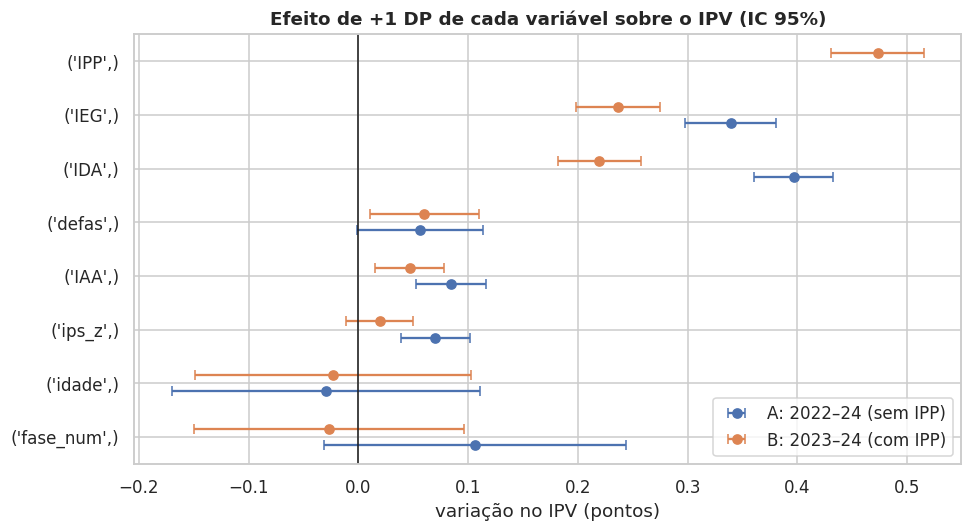

In [89]:
fig, ax = plt.subplots(figsize=(9, 5))
ordem = cB.sort_values("coef").index
for i, (nome, c, cor, off) in enumerate([("A: 2022–24 (sem IPP)", cA, "#4C72B0", -.15), ("B: 2023–24 (com IPP)", cB, "#DD8452", .15)]):
    cc = c.reindex([o for o in ordem if o in c.index])
    y = [list(ordem).index(o) + off for o in cc.index]
    ax.errorbar(cc.coef, y, xerr=[cc.coef - cc.ic95_inf, cc.ic95_sup - cc.coef], fmt="o", color=cor, capsize=3, label=nome)
ax.set_yticks(range(len(ordem))); ax.set_yticklabels(ordem); ax.axvline(0, color="k", lw=1)
ax.set_title("Efeito de +1 DP de cada variável sobre o IPV (IC 95%)"); ax.set_xlabel("variação no IPV (pontos)"); ax.legend()
plt.tight_layout(); plt.show()

O ponto de virada esta principalmente associado a avaliacao psicopedagogica, ao engajamento e ao desempenho. Idade, Fase e defasagem pesam pouco. Para analise forem feitas 2 leituras no ano de 2022, unico ano com marcador binario atingiu PV por Regressao logistica. IPV continuo em 2022-2024 sem IPP e 2023-2024 com IPP, por regressao linear padronizada. Em 2022, O marcador "Atingiu PV" equivale a um corte no IPV de mais ou menos 8,35, por isso o IPV nao entra como preditor. Nos demais indicadores, IDA (OR = 4,2 por +1 DP) e IEG (OR = 2,4) foram os mais fortes, seguidos por IAA (1,6) e IPS (1,4). Idade, fase e defasagem nao foram significativas. No IPV continuo, 2022.24 (sem IPP): +1 DP de IDA -> +0,40 e de IEG -> +0,35 ponto de IPV; IAA (+0,08) e IPS (+0,07) tem efeito pequeno. Nos anos 2023.24 (com IPP): o IPP passa a dominar (+0,48 por DP), a frente de IEG (+0,24) e IDA (+0,22); IPS fica em zero no modelo linear.